In [117]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import distance_transform_edt
from PIL import Image
import sys
sys.path.append('../../../')
from glob import glob
import tifffile as tiff
from scipy.ndimage import binary_dilation, binary_erosion
from skimage import feature
from scipy.ndimage import sobel


In [118]:
def compute_distance_map(instance_segmentation_map):
    """
    Computes the Euclidean Distance Transform (EDT) where boundaries have zero distance.
    
    Args:
        instance_segmentation_map (numpy.ndarray): Instance segmentation map where each object has a unique label.

    Returns:
        distance_map (numpy.ndarray): Distance map where each pixel represents the distance to the nearest boundary.
    """
    # Convert instance segmentation map to binary mask (foreground = 1, background = 0)
    binary_mask = (instance_segmentation_map > 0).astype(np.uint8)

    # Compute boundaries using morphological gradient
    padded = np.pad(binary_mask, pad_width=1, mode='constant', constant_values=0)
    eroded = padded[1:-1, 1:-1] & padded[:-2, 1:-1] & padded[2:, 1:-1] & \
             padded[1:-1, :-2] & padded[1:-1, 2:]  # Manual erosion

    boundary_mask = binary_mask - eroded  # Extracts boundaries

    # Set boundary pixels to 0 for distance transform
    binary_mask[boundary_mask > 0] = 0

    # Compute distance transform (distance from every pixel to the nearest boundary)
    distance_map = distance_transform_edt(binary_mask)

    return distance_map, boundary_mask

In [442]:
train_cell_img = tiff.imread('/group/jug/Sheida/Aitslab_bioimaging/test_cell_img.tif') # 36
train_cell_gt = tiff.imread('/group/jug/Sheida/Aitslab_bioimaging/test_cell_gt.tif')

train_nuclei_img = tiff.imread('/group/jug/Sheida/Aitslab_bioimaging/test_nuclei_img.tif') # 30
train_nuclei_gt = tiff.imread('/group/jug/Sheida/Aitslab_bioimaging/test_nuclei_gt.tif')

In [514]:
cell_index = 12
nuclei_index = 10

In [ ]:
cell = train_cell_img[cell_index]
cell_gt = train_cell_gt[cell_index]
nuclei = train_nuclei_img[nuclei_index]
nuclei_gt = train_nuclei_gt[nuclei_index]

In [509]:
_, cell_boundary = compute_distance_map(cell_gt)

In [510]:
cell_nuclei = np.stack([cell, nuclei], axis=0)
print(cell_nuclei.shape)

(2, 1104, 1104)


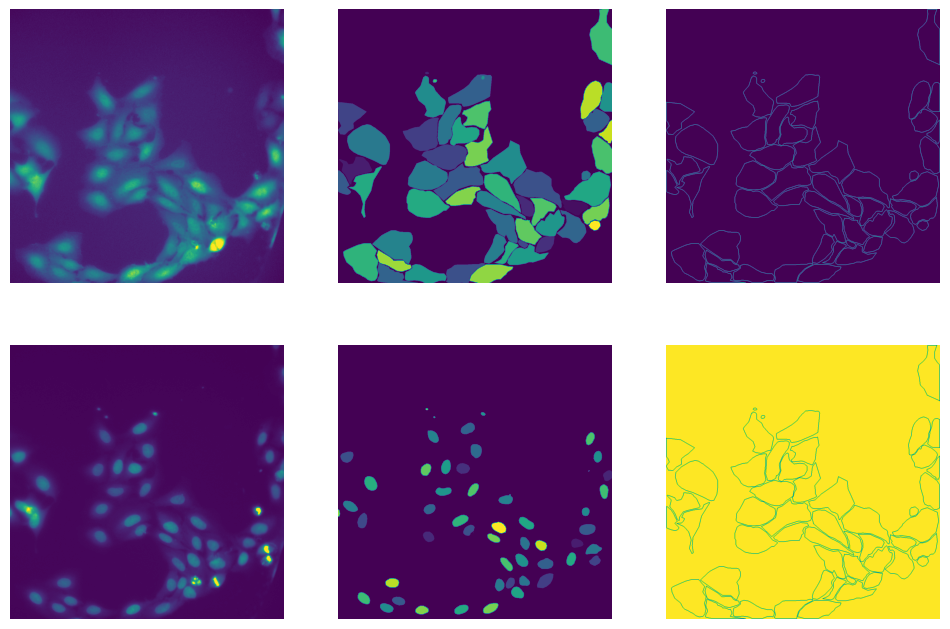

In [511]:
fig, ax = plt.subplots(2, 3, figsize=(12, 8))
# remove numbers in axes
for a in ax.ravel():
    a.axis('off')
ax[0, 0].imshow(cell_nuclei[0])
ax[0, 1].imshow(cell_gt)
ax[0, 2].imshow(cell_boundary)
ax[1, 0].imshow(cell_nuclei[1])
ax[1, 1].imshow(nuclei_gt)
ax[1, 2].imshow(~cell_boundary)
plt.show()

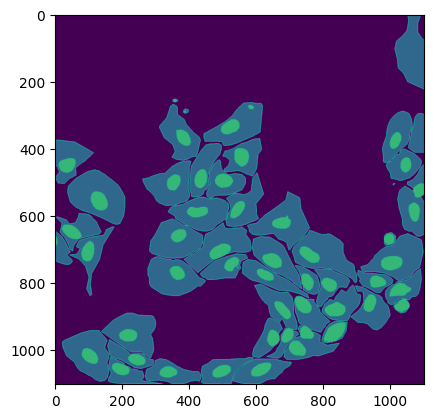

In [512]:
semantic_mask = np.zeros_like(cell, dtype=np.uint8)
semantic_mask[cell_gt > 0] = 1  # Cells get label 1
semantic_mask[cell_boundary > 0] = 3  # Cell boundary label 3
semantic_mask[nuclei_gt > 0] = 2  # Nuclei get label 2
plt.imshow(semantic_mask)

In [513]:
tiff.imwrite(f'/group/jug/Sheida/Aitslab_bioimaging/img/test/cell_{cell_index}_nuclei_{nuclei_index}.tif', cell_nuclei)
tiff.imwrite(f'/group/jug/Sheida/Aitslab_bioimaging/gt/test/cell_{cell_index}_nuclei_{nuclei_index}.tif', semantic_mask)

In [4]:
development_nuclei_1_img_paths = sorted(glob('/group/jug/Sheida/Aitslab_bioimaging/Aitslab_bioimaging1/development_nuclei/images/*.png'))
development_nuclei_1_gt_paths = sorted(glob('/group/jug/Sheida/Aitslab_bioimaging/Aitslab_bioimaging1/development_nuclei/annotations/*.png'))
for i in range(len(development_nuclei_1_img_paths)):
    if development_nuclei_1_img_paths[i][83:-4] != development_nuclei_1_gt_paths[i][88:-4]:
        print(development_nuclei_1_img_paths[i][83:-4], ' - ', development_nuclei_1_gt_paths[i][88:-4])

In [5]:
test_nuclei_1_img_paths = sorted(glob('/group/jug/Sheida/Aitslab_bioimaging/Aitslab_bioimaging1/test_nuclei/images/*.png'))
test_nuclei_1_gt_paths = sorted(glob('/group/jug/Sheida/Aitslab_bioimaging/Aitslab_bioimaging1/test_nuclei/annotations/*.png'))
for i in range(len(test_nuclei_1_img_paths)):
    if test_nuclei_1_img_paths[i][77:-4] != test_nuclei_1_gt_paths[i][82:-4]:
        print(test_nuclei_1_img_paths[i][77:-4], ' - ', test_nuclei_1_gt_paths[i][82:-4])

In [6]:
training_nuclei_2_img_paths = sorted(glob('/group/jug/Sheida/Aitslab_bioimaging/Aitslab_bioimaging2/12193890/train_cells/normalized_png/*.png'))
training_nuclei_2_gt_paths = sorted(glob('/group/jug/Sheida/Aitslab_bioimaging/Aitslab_bioimaging2/12193890/train_cells/annotations/*.png'))
for i in range(len(training_nuclei_2_img_paths)):
    if training_nuclei_2_img_paths[i][93:-4] != training_nuclei_2_gt_paths[i][90:-4]:
        print(training_nuclei_2_img_paths[i][93:-4], ' - ', training_nuclei_2_gt_paths[i][90:-4])

In [7]:
development_nuclei_2_img_paths = sorted(glob('/group/jug/Sheida/Aitslab_bioimaging/Aitslab_bioimaging2/12193890/development_cells/normalized_png/*.png'))
development_nuclei_2_gt_paths = sorted(glob('/group/jug/Sheida/Aitslab_bioimaging/Aitslab_bioimaging2/12193890/development_cells/annotations/*.png'))
for i in range(len(development_nuclei_2_img_paths)):
    if development_nuclei_2_img_paths[i][99:-4] != development_nuclei_2_gt_paths[i][96:-4]:
        print(development_nuclei_2_img_paths[i][99:-4], ' - ', development_nuclei_2_gt_paths[i][96:-4])

In [8]:
test_nuclei_2_img_paths = sorted(glob('/group/jug/Sheida/Aitslab_bioimaging/Aitslab_bioimaging2/12193890/test_cells/normalized_png/*.png'))
test_nuclei_2_gt_paths = sorted(glob('/group/jug/Sheida/Aitslab_bioimaging/Aitslab_bioimaging2/12193890/test_cells/annotations/*.png'))
for i in range(len(test_nuclei_2_img_paths)):
    if test_nuclei_2_img_paths[i][92:-4] != test_nuclei_2_gt_paths[i][89:-4]:
        print(test_nuclei_2_img_paths[i][92:-4], ' - ', test_nuclei_2_gt_paths[i][89:-4])

In [9]:
# Load images
img_list = [np.array(Image.open(p).convert("L")) for p in training_nuclei_1_img_paths]  
gt_list = [np.array(Image.open(p).convert("L")) for p in training_nuclei_1_gt_paths] 

images_np = np.stack(img_list, axis=0)  
gts_np = np.stack(gt_list, axis=0)

# Print shapes
print("Images shape:", images_np.shape)
print("GT shape:", gts_np.shape)

tiff.imwrite("/group/jug/Sheida/Aitslab_bioimaging/Aitslab_bioimaging1/training_nuclei/imgs.tif", images_np)
tiff.imwrite("/group/jug/Sheida/Aitslab_bioimaging/Aitslab_bioimaging1/training_nuclei/gts.tif", gts_np)


Images shape: (30, 1104, 1104)
GT shape: (30, 1104, 1104)


In [10]:
# Load images
img_list = [np.array(Image.open(p).convert("L")) for p in development_nuclei_1_img_paths]  
gt_list = [np.array(Image.open(p).convert("L")) for p in development_nuclei_1_gt_paths] 

images_np = np.stack(img_list, axis=0)  
gts_np = np.stack(gt_list, axis=0)

# Print shapes
print("Images shape:", images_np.shape)
print("GT shape:", gts_np.shape)

tiff.imwrite("/group/jug/Sheida/Aitslab_bioimaging/Aitslab_bioimaging1/development_nuclei/imgs.tif", images_np)
tiff.imwrite("/group/jug/Sheida/Aitslab_bioimaging/Aitslab_bioimaging1/development_nuclei/gts.tif", gts_np)


Images shape: (10, 1104, 1104)
GT shape: (10, 1104, 1104)


In [11]:
# Load images
img_list = [np.array(Image.open(p).convert("L")) for p in test_nuclei_1_img_paths]  
gt_list = [np.array(Image.open(p).convert("L")) for p in test_nuclei_1_gt_paths] 

images_np = np.stack(img_list, axis=0)  
gts_np = np.stack(gt_list, axis=0)

# Print shapes
print("Images shape:", images_np.shape)
print("GT shape:", gts_np.shape)

tiff.imwrite("/group/jug/Sheida/Aitslab_bioimaging/Aitslab_bioimaging1/test_nuclei/imgs.tif", images_np)
tiff.imwrite("/group/jug/Sheida/Aitslab_bioimaging/Aitslab_bioimaging1/test_nuclei/gts.tif", gts_np)


Images shape: (10, 1104, 1104)
GT shape: (10, 1104, 1104)


In [12]:
# Load images
img_list = [np.array(Image.open(p).convert("L")) for p in training_nuclei_2_img_paths]  
gt_list = [np.array(Image.open(p).convert("L")) for p in training_nuclei_2_gt_paths] 

images_np = np.stack(img_list, axis=0)  
gts_np = np.stack(gt_list, axis=0)

# Print shapes
print("Images shape:", images_np.shape)
print("GT shape:", gts_np.shape)

tiff.imwrite("/group/jug/Sheida/Aitslab_bioimaging/Aitslab_bioimaging2/12193890/train_cells/imgs.tif", images_np)
tiff.imwrite("/group/jug/Sheida/Aitslab_bioimaging/Aitslab_bioimaging2/12193890/train_cells/gts.tif", gts_np)


Images shape: (36, 1104, 1104)
GT shape: (36, 1104, 1104)


In [18]:
# Load images
img_list = [np.array(Image.open(p).convert("L")) for p in development_nuclei_2_img_paths]  
gt_list = [np.array(Image.open(p).convert("L")) for p in development_nuclei_2_gt_paths] 

images_np = np.stack(img_list, axis=0)  
gts_np = np.stack(gt_list, axis=0)

# Print shapes
print("Images shape:", images_np.shape)
print("GT shape:", gts_np.shape)

tiff.imwrite("/group/jug/Sheida/Aitslab_bioimaging/Aitslab_bioimaging2/12193890/development_cells/imgs.tif", images_np)
tiff.imwrite("/group/jug/Sheida/Aitslab_bioimaging/Aitslab_bioimaging2/12193890/development_cells/gts.tif", gts_np)


Images shape: (12, 1104, 1104)
GT shape: (12, 1104, 1104)


In [19]:
# Load images
img_list = [np.array(Image.open(p).convert("L")) for p in test_nuclei_2_img_paths]  
gt_list = [np.array(Image.open(p).convert("L")) for p in test_nuclei_2_gt_paths] 

images_np = np.stack(img_list, axis=0)  
gts_np = np.stack(gt_list, axis=0)

# Print shapes
print("Images shape:", images_np.shape)
print("GT shape:", gts_np.shape)

tiff.imwrite("/group/jug/Sheida/Aitslab_bioimaging/Aitslab_bioimaging2/12193890/test_cells/imgs.tif", images_np)
tiff.imwrite("/group/jug/Sheida/Aitslab_bioimaging/Aitslab_bioimaging2/12193890/test_cells/gts.tif", gts_np)


Images shape: (12, 1104, 1104)
GT shape: (12, 1104, 1104)


In [12]:
instance_map = Image.open("/home/sheida.rahnamai/EGFP/annotations/MFGTMPcx7_170607100001_K23f08d1_RA.png").convert("L")  # Convert to grayscale
instance_map = np.array(instance_map)  # Convert to NumPy array

# Compute the distance map
distance_map, boundary_mask = compute_distance_map(instance_map)

# Normalize for visualization
normalized_distance_map = distance_map / np.max(distance_map)

# Save distance map (if needed)
Image.fromarray((normalized_distance_map * 255).astype(np.uint8)).save("distance_map.png")

In [13]:
instance_map.shape

(1104, 1104)

(array([  0,  15,  19,  34,  38,  53,  57,  72,  75,  90,  94, 113, 128,
       133], dtype=uint8), array([932827,   2659,  58726,  22302,  41130,   4880,   2685,  21751,
         4294,  19131,  23079,   2521,  55766,  27065]))


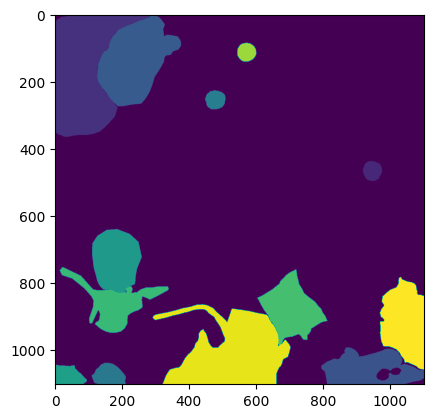

In [16]:
plt.imshow(instance_map)
print(np.unique(instance_map, return_counts=True))

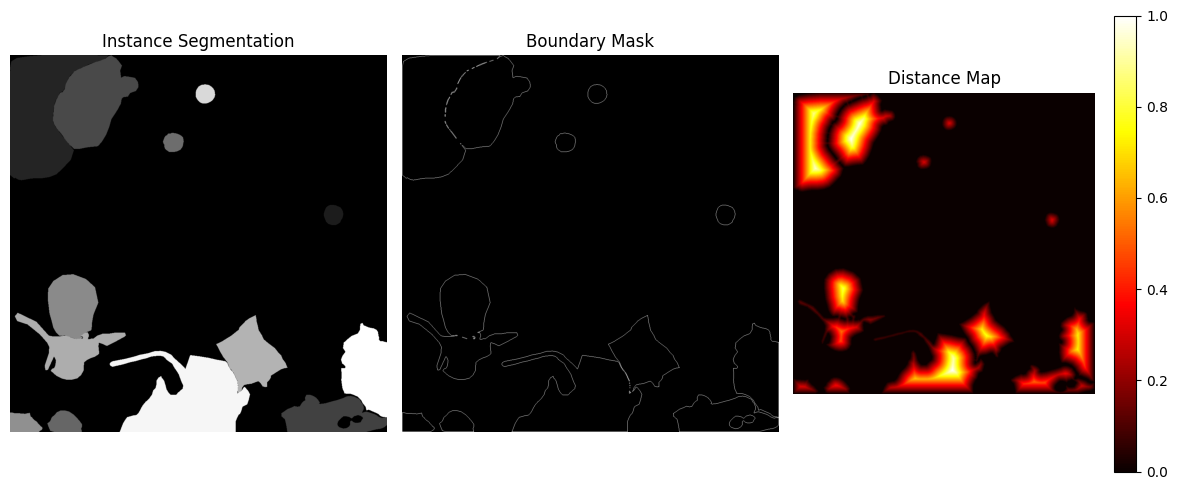

In [6]:
# Plot the results
plt.figure(figsize=(12, 5))

# Original Instance Segmentation Map
plt.subplot(1, 3, 1)
plt.imshow(instance_map, cmap="gray")
plt.title("Instance Segmentation")
plt.axis("off")

# Boundary Map
plt.subplot(1, 3, 2)
plt.imshow(boundary_mask, cmap="gray")
plt.title("Boundary Mask")
plt.axis("off")

# Distance Map with Boundaries as Zero
plt.subplot(1, 3, 3)
plt.imshow(normalized_distance_map, cmap="hot")
plt.colorbar()
plt.title("Distance Map")
plt.axis("off")

plt.tight_layout()
plt.show()
